In [ ]:

# CELL 1 - LOAD & BACKUP

# (steps: 1.import pandas 
# 2. download the ipl data from kaggle 
# 3. add the followign code for getting data here and then put file path in 
# 4. after downloading it , its very important that you choose "Extract all option ", only then it will be imported)

import pandas as pd



In [7]:
df = pd.read_csv("data/matches.csv")
df.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [ ]:
#  CELL 2 - INSPECT DATA 

# (check the shape and all and look how many rows and columns it have and gather info about it )

print(df.shape)   # gives no. of rows and columns (e.g. here we have [636 rows x 18 columns])
df.info           # gives info about structure of data


(636, 18)


<bound method DataFrame.info of       id  season       city        date                        team1  \
0      1    2017  Hyderabad  2017-04-05          Sunrisers Hyderabad   
1      2    2017       Pune  2017-04-06               Mumbai Indians   
2      3    2017     Rajkot  2017-04-07                Gujarat Lions   
3      4    2017     Indore  2017-04-08       Rising Pune Supergiant   
4      5    2017  Bangalore  2017-04-08  Royal Challengers Bangalore   
..   ...     ...        ...         ...                          ...   
631  632    2016     Raipur  2016-05-22             Delhi Daredevils   
632  633    2016  Bangalore  2016-05-24                Gujarat Lions   
633  634    2016      Delhi  2016-05-25          Sunrisers Hyderabad   
634  635    2016      Delhi  2016-05-27                Gujarat Lions   
635  636    2016  Bangalore  2016-05-29          Sunrisers Hyderabad   

                           team2                  toss_winner toss_decision  \
0    Royal Challengers B

In [10]:
#  CELL 3 - CHECK MISSING VALUES 

df.isnull().sum()  # .isnull() marks every cell as True(if missing ) or False(if it has a value) , and .sum()-> it then adds up those per column

#(e.g. city:7 -> this means 7 rows have no city listed, whereas 0 means it has no missing values)

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               3
win_by_runs          0
win_by_wickets       0
player_of_match      3
venue                0
umpire1              1
umpire2              1
umpire3            636
dtype: int64

In [14]:
#  CELL 4 - CLEAN


#  1.) FIX DATES 
#  2.) DROP  MATCHES  with no result 


df["date"] = pd.to_datetime(df["date"]) # if the date is not in the correct patter then it corrects it in numeral form 
df = df[df["winner"].notna()]           # it deletes the rows with no winners(may be they have tie or the match was not complete etc.)      
df.shape                                # thus after removing extra rows [636 rows ] changed to 633



(633, 18)

In [30]:
# CELL 5 - CLEAN:

# *** FIX INCONSISTENT TEAM NAMES

name_fixes = {

    "Delhi Daredevils": "Delhi Capitals",
    "Deccan Chargers": "Sunrises Hydrabad",
    "Kings XI Punjab": "Punjab Kings",
    "Rising Pune Supergiant": "Rising Pune Supergiants",
    "Sunrises Hydrabad": "Sunrisers Hyderabad"
}

for col in ["team1", "team2", "winner", "toss_winner"]:
    df[col] = df[col].replace(name_fixes)
df["team1"].unique()     # all names are fixed

array(['Sunrisers Hyderabad', 'Mumbai Indians', 'Gujarat Lions',
       'Rising Pune Supergiants', 'Royal Challengers Bangalore',
       'Kolkata Knight Riders', 'Delhi Capitals', 'Punjab Kings',
       'Chennai Super Kings', 'Rajasthan Royals', 'Kochi Tuskers Kerala',
       'Pune Warriors'], dtype=object)

In [31]:
# CELL 6 - CHECK DUPLICATES

df.duplicated().sum()  # removes duplicate elements

np.int64(0)

In [32]:
#  CELL 7 - EDA -> ASKING REAL QUESTIONS  (EXPLORATORY DATA ANALYSIS)

# 1.) Counts Top 10 highest to lowest winner list (telling how many times have they won)
print("Most match wins:\n", df["winner"].value_counts().head(10))

Most match wins:
 winner
Mumbai Indians                 92
Chennai Super Kings            79
Kolkata Knight Riders          77
Royal Challengers Bangalore    73
Sunrisers Hyderabad            71
Punjab Kings                   70
Rajasthan Royals               63
Delhi Capitals                 62
Rising Pune Supergiants        15
Gujarat Lions                  13
Name: count, dtype: int64


In [33]:
#  2.) Counts which stadiums show up most in venue
print("\nMost used venues:\n", df["venue"].value_counts().head(10))




Most used venues:
 venue
M Chinnaswamy Stadium                         64
Eden Gardens                                  61
Feroz Shah Kotla                              59
Wankhede Stadium                              57
Rajiv Gandhi International Stadium, Uppal     49
MA Chidambaram Stadium, Chepauk               48
Punjab Cricket Association Stadium, Mohali    35
Sawai Mansingh Stadium                        33
Dr DY Patil Sports Academy                    17
Subrata Roy Sahara Stadium                    17
Name: count, dtype: int64


In [20]:
#  3.) it answers "does winning the toss actually help you win the match."
# (toss winner and match winner checking row by row - It will be True if on winning toss a team has  won the match too, else False)
print("\nToss win -> match win rate:\n", (df["toss_winner"] == df["winner"]).value_counts(normalize=True))


Toss win -> match win rate:
 True     0.513428
False    0.486572
Name: proportion, dtype: float64


In [ ]:
#  4.) Counts matches per season, sorted by season number(in year), (not by count) 
print("\nMatches per season:\n", df["season"].value_counts().sort_index())


Matches per season:
 season
2008    58
2009    57
2010    60
2011    72
2012    74
2013    76
2014    60
2015    57
2016    60
2017    59
Name: count, dtype: int64


matplotlib imported successfully


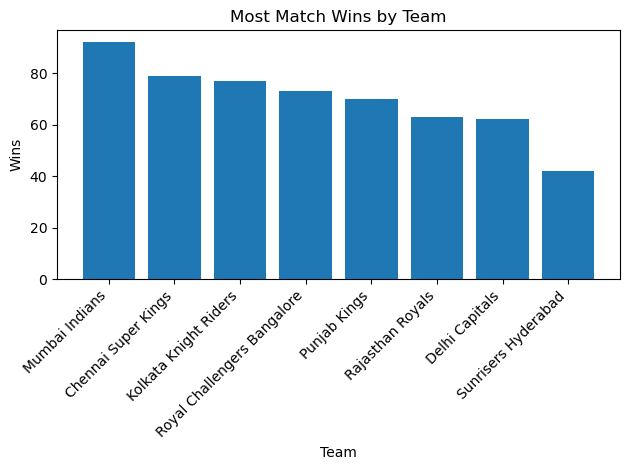

In [ ]:
#  CELL 8 - VISUALIZE : TEAM WINS 


# steps:)  for this 
#  1.) For Team Wins: *import matplotlib first for visual chart representation of data

import matplotlib.pyplot as plt
print("matplotlib imported successfully")

# *write the code to get your visual chart
import matplotlib.pyplot as plt

top_teams = df["winner"].value_counts().head(8)
plt.bar(top_teams.index, top_teams.values)
plt.xticks(rotation=45, ha="right")
plt.title("Most Match Wins by Team")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.tight_layout()
plt.show()


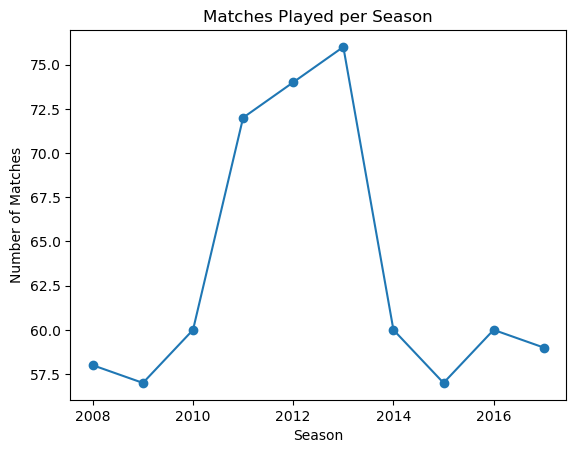

In [29]:
#  CELL 9 - VISUALIZE MATCHES PER SEASON

matches_per_season = df["season"].value_counts().sort_index()
plt.plot(matches_per_season.index, matches_per_season.values, marker="o")
plt.title("Matches Played per Season")
plt.xlabel("Season")
plt.ylabel("Season")
plt.ylabel("Number of Matches")
plt.show()

In [34]:
#  Thankyouu!!